#B22DCCN476 #Cell [1]. Import thư viện & cấu hình ban đầu

Trong cell này, em:

- Import các thư viện cần thiết:
  - **NumPy** và **Matplotlib** để xử lý số liệu và vẽ biểu đồ.
  - **TensorFlow/Keras** để xây dựng và huấn luyện mô hình deep learning cho dữ liệu văn bản:
    - `reuters` để tải dataset tin tức Reuters.
    - `layers`, `pad_sequences`, `to_categorical` để xây mô hình và tiền xử lý dữ liệu.
  - **scikit-learn** để:
    - Chia tập train/validation (`train_test_split`).
    - Tính **confusion matrix** và **classification report**.
- Đặt seed ngẫu nhiên cho `NumPy`, `TensorFlow` và `random` nhằm giúp kết quả có tính tái lập tương đối.
- In ra phiên bản TensorFlow đang sử dụng, tiện cho việc ghi chú trong báo cáo.


In [1]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [1]. Import thư viện & cấu hình ban đầu

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import reuters
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import random

# Đặt seed để kết quả tái lập tương đối
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


Cell [2]. Load dataset Reuters & thông tin cơ bản

- Em sử dụng `reuters.load_data(num_words=vocab_size, test_split=0.2)` để tải dataset:
  - **Reuters dataset**: tập tin tức ngắn, mỗi bản tin thuộc một trong 46 chủ đề (topics).
  - `vocab_size = 10000`: chỉ giữ lại 10.000 từ xuất hiện phổ biến nhất để:
    - Giảm kích thước embedding.
    - Giúp mô hình nhẹ hơn.
  - Dữ liệu được chia sẵn:
    - `x_train`, `y_train`: tập train.
    - `x_test`, `y_test`: tập test.
- `num_classes = max(y_train) + 1` ⇒ số lớp (chủ đề) trong bài toán (thường là 46).
- `reuters.get_word_index()` trả về mapping từ **từ** → **chỉ số**. Em đảo ngược thành:
  - `reverse_word_index`: từ **chỉ số** → **từ** để có thể **decode** chuỗi số thành văn bản.
- Hàm `decode_newswire(sequence)`:
  - Biến một chuỗi số (mã hóa tin tức) thành câu văn gần giống bản gốc.
- Đây là dataset **văn bản (text)**, nhẹ và phù hợp với yêu cầu bài tập.


In [2]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [2]. Load dataset Reuters & thông tin cơ bản

# Giới hạn kích thước từ vựng để mô hình nhẹ hơn
vocab_size = 10000

# Tải dữ liệu: mặc định test_split=0.2 (80% train, 20% test)
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=vocab_size, test_split=0.2)

print("Số mẫu train:", len(x_train))
print("Số mẫu test :", len(x_test))

num_classes = np.max(y_train) + 1
print("Số lớp (chủ đề) trong dataset:", num_classes)

# Lấy word_index để decode lại thành câu chữ
word_index = reuters.get_word_index()
reverse_word_index = {value+3: key for key, value in word_index.items()}
reverse_word_index[0] = "<pad>"
reverse_word_index[1] = "<start>"
reverse_word_index[2] = "<unk>"
reverse_word_index[3] = "<unused>"

def decode_newswire(sequence):
    return " ".join(reverse_word_index.get(i, "?") for i in sequence)


Số mẫu train: 8982
Số mẫu test : 2246
Số lớp (chủ đề) trong dataset: 46


***Cell [3]. Khám phá dữ liệu: phân bố lớp & ví dụ văn bản***

- Để **visualize phân bố data**, em:
  - Dùng `np.unique(y_train, return_counts=True)` để đếm số mẫu của từng lớp (0, 1, 2, ..., 45).
  - Vẽ biểu đồ cột (bar chart):
    - Trục x: nhãn lớp (ID chủ đề).
    - Trục y: số lượng mẫu trong tập train.
  - Nhận xét:
    - Một số lớp có nhiều mẫu, một số lớp ít hơn, nhưng nhìn chung dataset khá đa dạng.
- Sau đó, em **decode một vài newswire**:
  - Dùng hàm `decode_newswire` để biến chuỗi số thành chuỗi từ.
  - In ra 3 ví dụ ngẫu nhiên với:
    - Nội dung bản tin (rút gọn).
    - Nhãn lớp (chủ đề).
- Mục đích:
  - Thỏa yêu cầu **"visualize phân bố data"**.
  - Giúp người đọc hiểu rõ dataset là **tin tức văn bản** chứ không phải ảnh.


Phân bố số mẫu theo lớp (train):
  Lớp 0: 55 mẫu
  Lớp 1: 432 mẫu
  Lớp 2: 74 mẫu
  Lớp 3: 3159 mẫu
  Lớp 4: 1949 mẫu
  Lớp 5: 17 mẫu
  Lớp 6: 48 mẫu
  Lớp 7: 16 mẫu
  Lớp 8: 139 mẫu
  Lớp 9: 101 mẫu
  Lớp 10: 124 mẫu
  Lớp 11: 390 mẫu
  Lớp 12: 49 mẫu
  Lớp 13: 172 mẫu
  Lớp 14: 26 mẫu
  Lớp 15: 20 mẫu
  Lớp 16: 444 mẫu
  Lớp 17: 39 mẫu
  Lớp 18: 66 mẫu
  Lớp 19: 549 mẫu
  Lớp 20: 269 mẫu
  Lớp 21: 100 mẫu
  Lớp 22: 15 mẫu
  Lớp 23: 41 mẫu
  Lớp 24: 62 mẫu
  Lớp 25: 92 mẫu
  Lớp 26: 24 mẫu
  Lớp 27: 15 mẫu
  Lớp 28: 48 mẫu
  Lớp 29: 19 mẫu
  Lớp 30: 45 mẫu
  Lớp 31: 39 mẫu
  Lớp 32: 32 mẫu
  Lớp 33: 11 mẫu
  Lớp 34: 50 mẫu
  Lớp 35: 10 mẫu
  Lớp 36: 49 mẫu
  Lớp 37: 19 mẫu
  Lớp 38: 19 mẫu
  Lớp 39: 24 mẫu
  Lớp 40: 36 mẫu
  Lớp 41: 30 mẫu
  Lớp 42: 13 mẫu
  Lớp 43: 21 mẫu
  Lớp 44: 12 mẫu
  Lớp 45: 18 mẫu


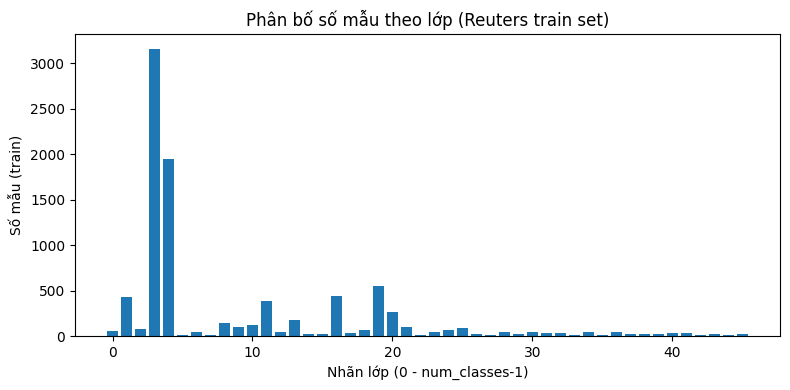


===== Một vài ví dụ newswire đã decode =====

--- Ví dụ 1 (index 1824) - Nhãn lớp: 3 ---
<start> shr 1 46 dlrs vs 1 41 dlrs net 277 5 mln vs 268 3 mln sales 2 13 billion vs 2 14 billion avg shrs 189 8 mln vs 189 8 mln nine mths shr 3 95 dlrs vs 3 78 dlrs net 750 5 mln vs 718 4 mln sales 6 28 billion vs 6 22 billion avg shrs 189 9 mln vs 190 2 mln reuter 3


--- Ví dụ 2 (index 409) - Nhãn lớp: 3 ---
<start> qtly div 10 cts vs 10 cts prior pay april 15 record april one reuter 3


--- Ví dụ 3 (index 4506) - Nhãn lớp: 16 ---
<start> marathon petroleum company a subsidiary of usx corp said it lowered posted prices for crude oil by 50 cts with an effective date of october 16 the increase brings posted prices for west texas intermediate and west texas sour to 19 00 dlrs a barrel each south louisiana sweet was increased to 19 35 dlrs a barrel several <unk> oil companies such as permian corp and coastal corp lt <unk> said they had moved prices up effective last friday the day sun co lt sun ann

In [3]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [3]. Khám phá dữ liệu: phân bố lớp & ví dụ văn bản

# Phân bố số mẫu theo lớp
unique, counts = np.unique(y_train, return_counts=True)
print("Phân bố số mẫu theo lớp (train):")
for label, cnt in zip(unique, counts):
    print(f"  Lớp {label}: {cnt} mẫu")

plt.figure(figsize=(8,4))
plt.bar(unique, counts)
plt.xlabel("Nhãn lớp (0 - num_classes-1)")
plt.ylabel("Số mẫu (train)")
plt.title("Phân bố số mẫu theo lớp (Reuters train set)")
plt.tight_layout()
plt.show()

# Xem một vài ví dụ văn bản
num_examples = 3
print("\n===== Một vài ví dụ newswire đã decode =====\n")
for i in range(num_examples):
    idx = random.randint(0, len(x_train)-1)
    print(f"--- Ví dụ {i+1} (index {idx}) - Nhãn lớp: {y_train[idx]} ---")
    print(decode_newswire(x_train[idx])[:1000])  # in tối đa 1000 ký tự
    print("\n")


***Cell [4]. Tiền xử lý text: padding, chia train/val, one-hot***

- **Padding chuỗi**:
  - Các newswire có độ dài khác nhau.
  - Dùng `pad_sequences` với `maxlen = 200`:
    - Chuỗi dài hơn 200 từ sẽ bị cắt bớt.
    - Chuỗi ngắn hơn 200 từ sẽ được thêm `<pad>` ở đầu để đủ độ dài.
  - Kết quả:
    - `x_train_pad` và `x_test_pad` có shape `(số mẫu, 200)`.
- **Chia train/validation**:
  - Dùng `train_test_split`:
    - 80% (của train ban đầu) dùng để huấn luyện (`x_train_pad`, `y_train`).
    - 20% dùng để validation (`x_val_pad`, `y_val`).
  - Tham số `stratify=y_train` giúp giữ phân bố lớp cân bằng giữa train và validation.
- **Mã hóa nhãn (labels) sang one-hot**:
  - Dataset có `num_classes` chủ đề (thường là 46).
  - Mỗi nhãn `y` được chuyển sang vector one-hot dài `num_classes`.
- Sau cell này, dữ liệu đã ở dạng phù hợp cho mô hình deep learning:
  - Input: ma trận số nguyên `(batch_size, maxlen)`.
  - Output: nhãn one-hot `(batch_size, num_classes)`.


In [4]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [4]. Tiền xử lý text: padding, chia train/val, one-hot

# Giới hạn độ dài chuỗi để mô hình nhẹ hơn
maxlen = 200

# Padding chuỗi (cắt hoặc thêm <pad> cho đủ độ dài)
x_train_pad = pad_sequences(x_train, maxlen=maxlen)
x_test_pad  = pad_sequences(x_test, maxlen=maxlen)

print("Kích thước x_train_pad:", x_train_pad.shape)
print("Kích thước x_test_pad :", x_test_pad.shape)

# Chia train/val từ x_train_pad
x_train_pad, x_val_pad, y_train, y_val = train_test_split(
    x_train_pad, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Kích thước x_train_pad (sau chia):", x_train_pad.shape)
print("Kích thước x_val_pad             :", x_val_pad.shape)

# One-hot cho nhãn
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat   = to_categorical(y_val, num_classes=num_classes)
y_test_cat  = to_categorical(y_test, num_classes=num_classes)

print("Ví dụ nhãn trước one-hot:", y_train[0])
print("Ví dụ nhãn sau one-hot  :", y_train_cat[0])


Kích thước x_train_pad: (8982, 200)
Kích thước x_test_pad : (2246, 200)
Kích thước x_train_pad (sau chia): (7185, 200)
Kích thước x_val_pad             : (1797, 200)
Ví dụ nhãn trước one-hot: 3
Ví dụ nhãn sau one-hot  : [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


***Cell [5]. Xây mô hình BiLSTM lớn (dễ bị overfitting)***

- Em xây dựng mô hình xử lý văn bản theo pipeline:
  1. **Embedding layer**:
     - `Embedding(vocab_size, embedding_dim, input_length=maxlen)`:
       - Biểu diễn mỗi từ dưới dạng một vector liên tục chiều `embedding_dim` (128).
       - Học được mối quan hệ ngữ nghĩa giữa các từ.
  2. **Bidirectional LSTM**:
     - `Bidirectional(LSTM(128))`:
       - LSTM 128 units đọc chuỗi theo 2 chiều (forward + backward).
       - Mô hình rất mạnh, dễ học được pattern phức tạp trong câu.
  3. **Dense 128 neurons (ReLU)**:
       - Lớp fully-connected lớn, tăng số lượng tham số.
  4. **Output Dense (softmax)**:
       - Kích thước = `num_classes` (số chủ đề).
       - Dự đoán phân phối xác suất trên các lớp.

- Điểm quan trọng:
  - Mô hình **không dùng Dropout**, **không L2**, **không regularization**, nhưng lại khá lớn.
  - Điều này khiến mô hình **rất dễ bị overfitting**, đúng yêu cầu đề bài: “training loss giảm nhưng val_loss tăng”.


In [5]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [5]. Xây mô hình BiLSTM lớn (dễ bị overfitting)

embedding_dim = 128

def build_overfit_text_model(vocab_size, embedding_dim, maxlen, num_classes):
    model = keras.Sequential()
    model.add(layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=maxlen))
    model.add(layers.Bidirectional(layers.LSTM(128, return_sequences=False)))
    model.add(layers.Dense(128, activation="relu"))  # layer lớn, không regularization
    # Không dropout, không L2
    model.add(layers.Dense(num_classes, activation="softmax"))
    return model

overfit_model = build_overfit_text_model(vocab_size, embedding_dim, maxlen, num_classes)
overfit_model.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

***Cell [6]. Compile & train mô hình overfit (text)***

- Em compile mô hình với:
  - **Optimizer**: Adam (learning_rate = 1e-3).
  - **Loss**: `categorical_crossentropy` (phân loại đa lớp).
  - **Metric**: `accuracy`.
- Huấn luyện:
  - `epochs=20`: số epoch đủ lớn để mô hình có thời gian **học rất kỹ dữ liệu train**.
  - `batch_size=64`: kích thước mini-batch phổ biến, cân bằng giữa tốc độ và độ ổn định.
  - `validation_data=(x_val_pad, y_val_cat)`: dùng tập validation để tính `val_loss` và `val_accuracy`.
- Kỳ vọng:
  - Sau vài epoch, `training loss` tiếp tục giảm trong khi `validation loss` bắt đầu **tăng dần**:
    - Đây là dấu hiệu mô hình **overfit** trên tập train.


In [6]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [6]. Compile & train mô hình overfit (text)

overfit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_overfit = overfit_model.fit(
    x_train_pad, y_train_cat,
    epochs=20,           # train khá nhiều epoch để dễ thấy overfitting
    batch_size=64,
    validation_data=(x_val_pad, y_val_cat),
    verbose=1
)


Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 29s 231ms/step - accuracy: 0.4522 - loss: 2.1959 - val_accuracy: 0.5370 - val_loss: 1.8777
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 239ms/step - accuracy: 0.5421 - loss: 1.7805 - val_accuracy: 0.5442 - val_loss: 1.7253
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 28s 246ms/step - accuracy: 0.5471 - loss: 1.7187 - val_accuracy: 0.5648 - val_loss: 1.7673
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 28s 248ms/step - accuracy: 0.5722 - loss: 1.6360 - val_accuracy: 0.5854 - val_loss: 1.6384
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 242ms/step - accuracy: 0.6061 - loss: 1.5105 - val_accuracy: 0.5876 - val_loss: 1.6013
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 242ms/step - accuracy: 0.6327 - loss: 1.3912 - val_accuracy: 0.6127 - val_loss: 1.5743
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 242ms/step - accuracy: 0.6559 - loss: 1.3164 - val_accuracy: 0.6066 - val_loss: 1.6269
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 28s 250ms/step - accuracy: 0.6756 - loss: 1

***Cell [7]. Vẽ lịch sử loss/accuracy cho mô hình overfit***

- Hàm `plot_training_history`:
  - Lấy `history.history` chứa:
    - `loss`, `accuracy`: trên tập train.
    - `val_loss`, `val_accuracy`: trên tập validation.
  - Vẽ 2 biểu đồ:
    1. **Loss vs Epoch**:
       - `Training loss`: độ lỗi trên train.
       - `Validation loss`: độ lỗi trên validation.
    2. **Accuracy vs Epoch**:
       - `Training accuracy` và `Validation accuracy`.
- Khi quan sát:
  - Nếu thấy:
    - `Training loss` ↓ liên tục.
    - `Validation loss` sau một điểm nào đó ↑ ngược trở lại.
  - Thì đây là log chứng minh mô hình **overfitting**:
    - Học quá kỹ dữ liệu train.
    - Khả năng tổng quát trên dữ liệu mới (validation/test) kém đi.
- Biểu đồ này chính là phần **“Cho log training loss giảm nhưng val_loss tăng”** theo yêu cầu đề bài.


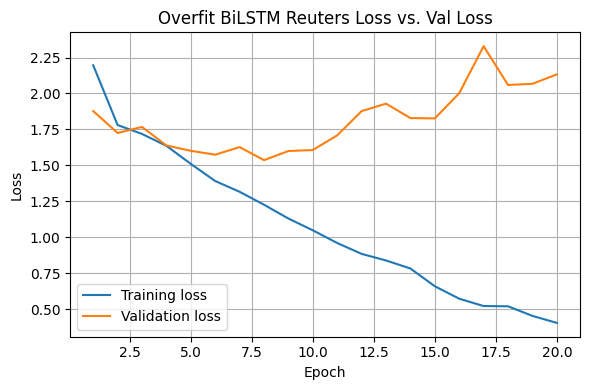

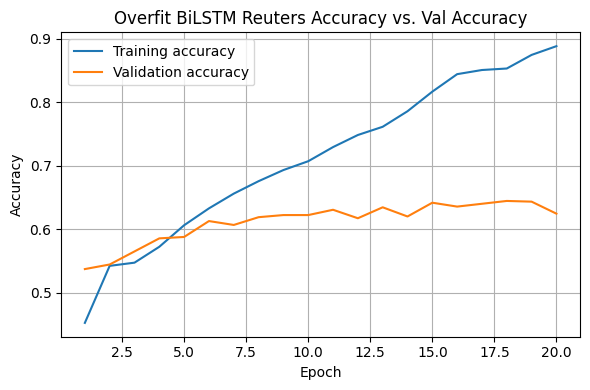

In [7]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [7]. Vẽ lịch sử loss/accuracy cho mô hình overfit

def plot_training_history(history, title_prefix=""):
    history_dict = history.history
    epochs = range(1, len(history_dict["loss"]) + 1)
    
    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(epochs, history_dict["loss"], label="Training loss")
    plt.plot(epochs, history_dict["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss vs. Val Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Accuracy
    plt.figure(figsize=(6,4))
    plt.plot(epochs, history_dict["accuracy"], label="Training accuracy")
    plt.plot(epochs, history_dict["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy vs. Val Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_training_history(history_overfit, title_prefix="Overfit BiLSTM Reuters")


***Cell [8]. Đánh giá mô hình overfit & vẽ Confusion Matrix***

- Đầu tiên, em đánh giá mô hình overfit trên **tập test**:
  - `test_loss_overfit`, `test_acc_overfit` cho biết chất lượng mô hình trên dữ liệu chưa thấy.
  - Thường overfitting ⇒ `test_acc` không cao tương xứng với `training accuracy`.
- Sau đó:
  - Dùng `model.predict` trên `x_test_pad` để lấy xác suất dự đoán từng lớp.
  - Dùng `argmax` để chuyển về nhãn dự đoán `y_pred`.
  - So sánh với nhãn thật `y_true = y_test`.
- **Confusion matrix**:
  - Dùng `confusion_matrix(y_true, y_pred)` để tạo ma trận nhầm lẫn kích thước `(num_classes, num_classes)`.
  - Vẽ dạng heatmap:
    - Phiên bản **normalized** (theo hàng) giúp thấy tỷ lệ phần trăm dự đoán đúng/sai cho từng lớp.
- **Classification report**:
  - In các chỉ số `precision`, `recall`, `f1-score` cho từng lớp.
  - Giúp phân tích lớp nào mô hình nhận diện tốt, lớp nào còn kém.
- Kết quả:
  - Kết hợp với log ở Cell [7], đây là bằng chứng mô hình đã **overfit**:
    - Training tốt nhưng hiệu suất trên test/validation không tương ứng.


Test loss (overfit model): 2.2520
Test acc  (overfit model): 0.6202

Confusion matrix (normalized):


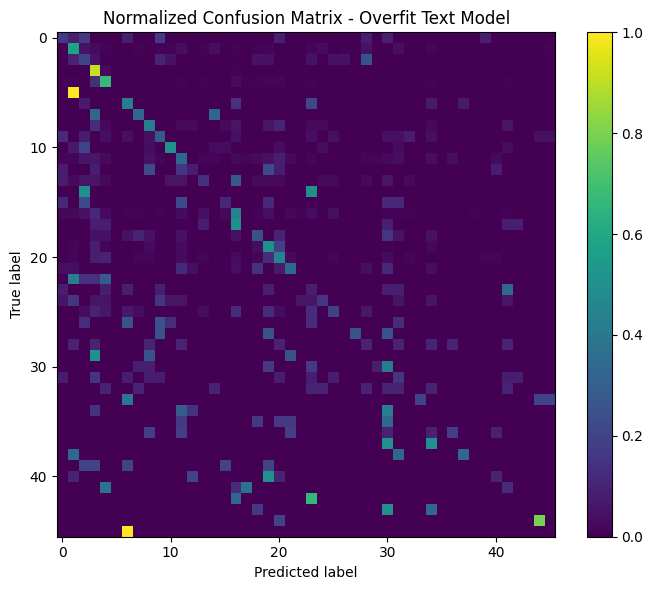


Classification report (tóm tắt):
              precision    recall  f1-score   support

           0      0.083     0.167     0.111        12
           1      0.635     0.581     0.607       105
           2      0.100     0.200     0.133        20
           3      0.855     0.915     0.884       813
           4      0.862     0.671     0.754       474
           5      0.000     0.000     0.000         5
           6      0.300     0.429     0.353        14
           7      0.071     0.333     0.118         3
           8      0.356     0.421     0.386        38
           9      0.304     0.280     0.292        25
          10      0.714     0.500     0.588        30
          11      0.438     0.337     0.381        83
          12      0.143     0.077     0.100        13
          13      0.250     0.135     0.175        37
          14      0.000     0.000     0.000         2
          15      0.125     0.111     0.118         9
          16      0.431     0.444     0.438    

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [8]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [8]. Đánh giá mô hình overfit & vẽ Confusion Matrix

# Đánh giá trên tập test
test_loss_overfit, test_acc_overfit = overfit_model.evaluate(x_test_pad, y_test_cat, verbose=0)
print(f"Test loss (overfit model): {test_loss_overfit:.4f}")
print(f"Test acc  (overfit model): {test_acc_overfit:.4f}")

# Dự đoán trên tập test
y_pred_prob = overfit_model.predict(x_test_pad, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test

# Tính confusion matrix
cm = confusion_matrix(y_true, y_pred)

def plot_confusion_matrix(cm, normalize=False, title="Confusion matrix"):
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    
    plt.figure(figsize=(7,6))
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(title)
    plt.colorbar()
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

print("\nConfusion matrix (normalized):")
plot_confusion_matrix(cm, normalize=True, title="Normalized Confusion Matrix - Overfit Text Model")

print("\nClassification report (tóm tắt):")
print(classification_report(y_true, y_pred, digits=3))


***Cell [9]. Xây mô hình BiLSTM cải tiến (regularization)***

Mục tiêu: **giảm overfitting** bằng cách thêm các kỹ thuật regularization:

1. **Embedding + SpatialDropout1D(0.3)**:
   - `SpatialDropout1D` tắt ngẫu nhiên **cả vector embedding** của một số từ trong câu.
   - Giúp mô hình không quá phụ thuộc vào một vài từ cụ thể.

2. **Bidirectional LSTM nhỏ hơn**:
   - Dùng `LSTM(64)` thay vì `LSTM(128)`:
     - Giảm số lượng tham số.
     - Vẫn giữ được khả năng học ngữ cảnh.
   - Thêm `dropout=0.3` và `recurrent_dropout=0.3`:
     - Regularization trực tiếp trên LSTM.

3. **Dense 64 neurons + L2 + Dropout**:
   - Lớp Dense 64 neuron với `kernel_regularizer=l2(1e-4)`:
     - Phạt trọng số quá lớn ⇒ buộc mô hình học đơn giản hơn.
   - `Dropout(0.5)` sau Dense:
     - Mỗi lần train "tắt" ngẫu nhiên 50% neuron ⇒ giảm overfitting.

4. **Output Dense (softmax)**:
   - Kích thước = số lớp (num_classes), activation `softmax`.

Kỳ vọng:
- Đường `val_loss` ổn định hơn.
- Khoảng cách giữa `loss` và `val_loss` nhỏ hơn.
- **Test accuracy** được cải thiện so với mô hình overfit.


In [9]:
#B22DCCN476 #Cell [9]. Xây mô hình BiLSTM cải tiến (regularization)

embedding_dim = 128

def build_improved_text_model(vocab_size, embedding_dim, maxlen, num_classes):
    inputs = keras.Input(shape=(maxlen,))
    
    x = layers.Embedding(vocab_size, embedding_dim, input_length=maxlen)(inputs)
    x = layers.SpatialDropout1D(0.2)(x)  # dropout trên embedding
    
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)
    )(x)
    
    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-4)
    )(x)
    x = layers.Dropout(0.2)(x)
    
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="improved_bilstm_reuters")
    return model

improved_model = build_improved_text_model(vocab_size, embedding_dim, maxlen, num_classes)
improved_model.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "improved_bilstm_reuters"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_1 (Embedding)              │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (None, 200, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 46)                  │           2,990 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,390,062 (5.30 MB)

 Trainable params: 1,390,062 (5.30 MB)

 Non-trainable params: 0 (0.00 B)

***Cell [10]. Compile & train mô hình cải tiến với EarlyStopping***

- Compile mô hình cải tiến với:
  - Optimizer: Adam, lr = 1e-3.
  - Loss: categorical_crossentropy.
  - Metric: accuracy.
- Áp dụng **EarlyStopping**:
  - `monitor="val_loss"`: theo dõi lỗi trên tập validation.
  - `patience=4`: nếu sau 4 epoch liên tiếp `val_loss` không cải thiện ⇒ dừng train.
  - `restore_best_weights=True`: quay lại trọng số tại epoch có `val_loss` thấp nhất.
- Training:
  - `epochs=30`: số epoch tối đa, nhưng EarlyStopping sẽ tự động dừng sớm nếu mô hình bắt đầu overfit.
- Lợi ích:
  - Hạn chế việc tiếp tục huấn luyện khi mô hình không còn cải thiện trên validation.
  - Giảm overfitting và tiết kiệm thời gian.


In [10]:
#B22DCCN476 - Đỗ Ngọc Lâm 
#Cell [10]. Compile & train mô hình cải tiến với EarlyStopping

improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_improved = improved_model.fit(
    x_train_pad, y_train_cat,
    epochs=30,           # cho phép nhiều epoch, EarlyStopping sẽ dừng sớm nếu cần
    batch_size=128,
    validation_data=(x_val_pad, y_val_cat),
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 31s 485ms/step - accuracy: 0.3631 - loss: 2.6338 - val_accuracy: 0.4686 - val_loss: 2.0974
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 469ms/step - accuracy: 0.4888 - loss: 2.0070 - val_accuracy: 0.5203 - val_loss: 1.8560
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 468ms/step - accuracy: 0.5296 - loss: 1.8221 - val_accuracy: 0.5426 - val_loss: 1.7451
Epoch 4/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 473ms/step - accuracy: 0.5588 - loss: 1.7169 - val_accuracy: 0.5531 - val_loss: 1.7167
Epoch 5/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 471ms/step - accuracy: 0.5762 - loss: 1.6459 - val_accuracy: 0.5737 - val_loss: 1.6842
Epoch 6/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 472ms/step - accuracy: 0.5939 - loss: 1.5880 - val_accuracy: 0.5710 - val_loss: 1.6817
Epoch 7/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 475ms/step - accuracy: 0.6139 - loss: 1.5237 - val_accuracy: 0.5782 - val_loss: 1.6873
Epoch 8/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 27s 473ms/step - accuracy: 0.6221 - loss: 1.5014 - val_accu

***Cell [11]. So sánh lịch sử huấn luyện & đánh giá mô hình cải tiến***

- Dùng lại hàm `plot_training_history` để vẽ:
  - `loss` vs `val_loss`.
  - `accuracy` vs `val_accuracy` cho mô hình cải tiến.
- Khi quan sát:
  - Kỳ vọng thấy:
    - `val_loss` không tăng mạnh như mô hình overfit.
    - Đường `loss` và `val_loss` gần nhau hơn.
    - `val_accuracy` ổn định hơn.
- Đánh giá trên test:
  - So sánh:
    - `test_acc_overfit` (mô hình ban đầu).
    - `test_acc_improved` (mô hình cải tiến).
  - Nếu mô hình cải tiến tốt:
    - `test_acc_improved` ≥ `test_acc_overfit`.
    - Overfitting giảm (train/val/test gần nhau hơn).
- Vẽ **confusion matrix** cho mô hình cải tiến:
  - Phiên bản normalized cho thấy tỷ lệ dự đoán đúng theo từng lớp.
- In **classification report**:
  - So sánh với mô hình cũ về precision, recall, F1-score.
- Kết luận:
  - Sau khi thêm **data regularization (dropout, L2, EarlyStopping)**, mô hình:
    - Giảm hiện tượng overfitting (val_loss ổn định hơn).
    - Tăng khả năng tổng quát hóa trên tập test (test accuracy tốt hơn).


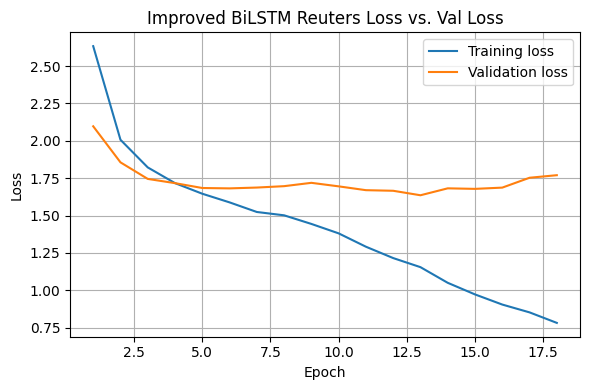

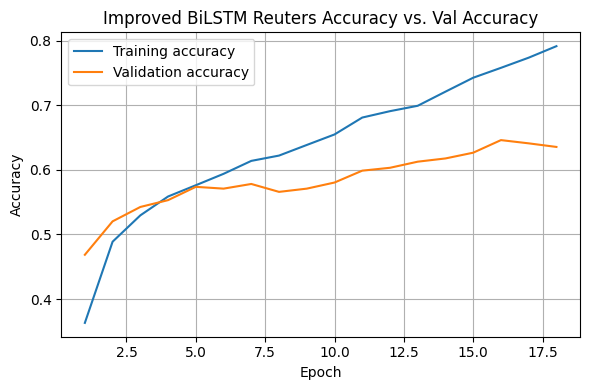

Test loss (improved model): 1.6817
Test acc  (improved model): 0.6095

So sánh nhanh giữa hai mô hình:
  Overfit model  - Test acc: 0.6202
  Improved model - Test acc: 0.6095

Confusion matrix (Improved model - normalized):


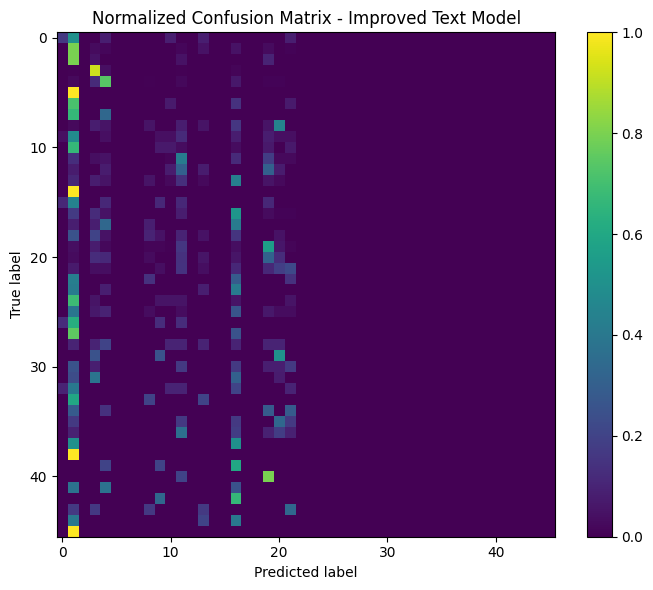


Classification report (Improved model):
              precision    recall  f1-score   support

           0      0.333     0.167     0.222        12
           1      0.283     0.800     0.418       105
           2      0.000     0.000     0.000        20
           3      0.863     0.923     0.892       813
           4      0.812     0.741     0.775       474
           5      0.000     0.000     0.000         5
           6      0.000     0.000     0.000        14
           7      0.000     0.000     0.000         3
           8      0.111     0.053     0.071        38
           9      0.077     0.040     0.053        25
          10      0.154     0.067     0.093        30
          11      0.271     0.422     0.330        83
          12      0.000     0.000     0.000        13
          13      0.043     0.027     0.033        37
          14      0.000     0.000     0.000         2
          15      0.000     0.000     0.000         9
          16      0.268     0.525     0.

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [11]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [11]. So sánh lịch sử huấn luyện & đánh giá mô hình cải tiến

# Vẽ lịch sử huấn luyện mô hình cải tiến
plot_training_history(history_improved, title_prefix="Improved BiLSTM Reuters")

# Đánh giá trên tập test
test_loss_improved, test_acc_improved = improved_model.evaluate(x_test_pad, y_test_cat, verbose=0)
print(f"Test loss (improved model): {test_loss_improved:.4f}")
print(f"Test acc  (improved model): {test_acc_improved:.4f}")

print("\nSo sánh nhanh giữa hai mô hình:")
print(f"  Overfit model  - Test acc: {test_acc_overfit:.4f}")
print(f"  Improved model - Test acc: {test_acc_improved:.4f}")

# Confusion matrix cho mô hình cải tiến
y_pred_prob_imp = improved_model.predict(x_test_pad, verbose=0)
y_pred_imp = np.argmax(y_pred_prob_imp, axis=1)
cm_imp = confusion_matrix(y_test, y_pred_imp)

print("\nConfusion matrix (Improved model - normalized):")
plot_confusion_matrix(cm_imp, normalize=True, title="Normalized Confusion Matrix - Improved Text Model")

print("\nClassification report (Improved model):")
print(classification_report(y_test, y_pred_imp, digits=3))
